In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# ================================
# 1. Load dataset
# ================================
df = pd.read_csv("wine.csv")

print(df.head())
print(df.columns)

   Cultivar  Alcohol  Malic acid   Ash  Alcalinity of ash  Magnesium  \
0         1    14.23        1.71  2.43               15.6        127   
1         1    13.20        1.78  2.14               11.2        100   
2         1    13.16        2.36  2.67               18.6        101   
3         1    14.37        1.95  2.50               16.8        113   
4         1    13.24        2.59  2.87               21.0        118   

   Total phenols  Flavanoids  Nonflavanoid phenols  Proanthocyanins  \
0           2.80        3.06                  0.28             2.29   
1           2.65        2.76                  0.26             1.28   
2           2.80        3.24                  0.30             2.81   
3           3.85        3.49                  0.24             2.18   
4           2.80        2.69                  0.39             1.82   

   Color intensity   Hue  OD280/OD315 of diluted wines  Proline  
0             5.64  1.04                          3.92     1065  
1       

In [3]:
# ================================
# 2. Split features and label
# ================================
X = df.drop("Cultivar", axis=1)

# use original Cultivar labels directly
y = df["Cultivar"]
# ================================
# 3. Perform Label Encoding
# ================================
encoder = LabelEncoder()

# convert labels into 0,1,2
y_encoded = encoder.fit_transform(y)

print("Original labels:")
print(y.unique())

print("Encoded labels:")
print(np.unique(y_encoded))
# ================================
# 4. Split dataset
# 10% testing
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.10,
    random_state=42,
    stratify=y_encoded
)

Original labels:
[1 2 3]
Encoded labels:
[0 1 2]


In [4]:
# ================================
# 4. Standardize dataset
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
# ================================
# 5. Perform PCA
# ================================
pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total variance captured:")
print(pca.explained_variance_ratio_.sum())


Explained variance ratio:
[0.35739433 0.19044807 0.11546883 0.0727021  0.06490112]
Total variance captured:
0.8009144469478355


In [6]:
# ================================
# 6. Build Neural Network
# ================================
model = keras.Sequential([
    keras.Input(shape=(5,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])


In [7]:
# ================================
# 7. Compile model
# ================================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [10]:
# ================================
# 8. Train model
# ================================
history = model.fit(
    X_train_pca,
    y_train,
    epochs=80,
    validation_data=(X_test_pca, y_test),
    verbose=1
)

Epoch 1/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4000 - loss: 1.0996 - val_accuracy: 0.6111 - val_loss: 0.9961
Epoch 2/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4688 - loss: 1.0498 - val_accuracy: 0.6667 - val_loss: 0.9492
Epoch 3/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5000 - loss: 1.0057 - val_accuracy: 0.7222 - val_loss: 0.9068
Epoch 4/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5188 - loss: 0.9647 - val_accuracy: 0.7222 - val_loss: 0.8671
Epoch 5/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5625 - loss: 0.9274 - val_accuracy: 0.7778 - val_loss: 0.8295
Epoch 6/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5750 - loss: 0.8924 - val_accuracy: 0.7778 - val_loss: 0.7930
Epoch 7/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6062 - loss: 0.8612 - val_accuracy: 0.7778 - val_loss: 0.7576
Epoch 8/80
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6562 - loss: 0.8295 - val_accuracy: 0.8333 - val_loss: 0.7242


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 1.0000 - loss: 0.0733
Test Loss: 0.07329317927360535
Test Accuracy: 1.0


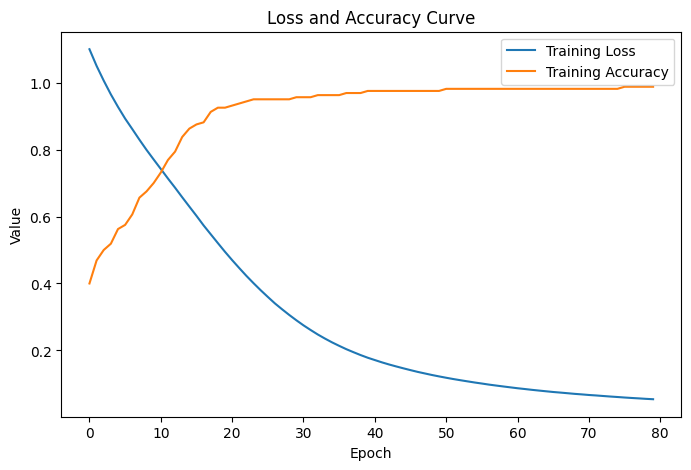

In [11]:
# ================================
# 9. Evaluate model
# ================================
test_loss, test_accuracy = model.evaluate(
    X_test_pca,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

# ================================
# 10. Plot loss and accuracy
# ================================
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Loss and Accuracy Curve")

plt.legend()

plt.show()


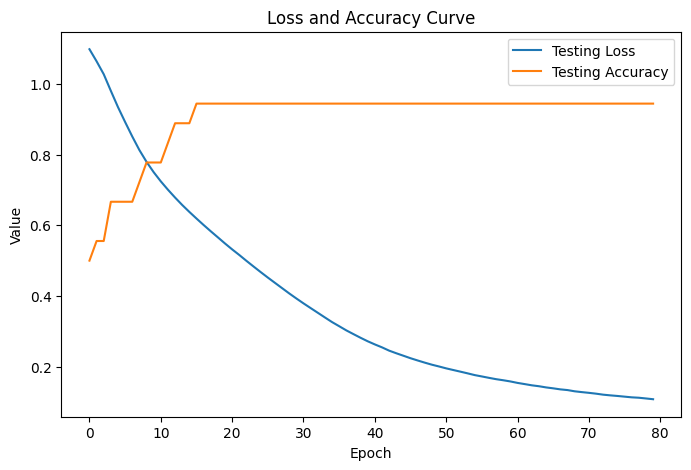

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"], label="Testing Loss")
plt.plot(history.history["val_accuracy"], label="Testing Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Value")

plt.title("Loss and Accuracy Curve")

plt.legend()

plt.show()

The end